# Mini Project 4 -- CBO
#### Monika Zeng, AJ Aizpurua

##### We explored nltk library and specifically focused on unigrams, bigrams and trigrams,  and also experimented some other functionalities, such as looking at extracting n-grams, unusual words, cumulative frequency diagram

##### For Iliad and Odyssey, we printed out the most common unigrams, bigrams and trigrams and rare words as well for each versions of texts. Then we looked at the differences of the sentence length for each versions of translations and produced bar graphs to provide better visualization

##### We collected in total of 6 versions of English translation text of Iliad and 5 versions of English translations of Odyssey
##### We looked at 4 foreign language versions as well (Greek (original), Spanish, French, Finnish)

##### We wrote our own my_util.py file for some commonly used functions

In [1]:
import os
import nltk 
import nltk, re, pprint
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.util import ngrams
from nltk.corpus import udhr
from nltk import FreqDist
from nltk.tokenize import PunktSentenceTokenizer
import matplotlib.pyplot as plt

import time
import string
import random
from my_util import preprocessing, remove_stopwords, unigram_stopwords

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download ("popular")
nltk.download('cess_esp')
nltk.download('udhr')

[nltk_data] Downloading package punkt to /Users/monika/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/monika/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /Users/monika/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /Users/monika/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /Users/monika/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /Users/monika/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to

True

#### Input files for English translations

In [3]:
Iliad = ["./data/Il_Butler.txt", "./data/Il_Chapman.txt", 
             "./data/Il_Collins.txt","./data/Il_Cowper.txt","./data/Il_Edward.txt", "./data/Il_Lang.txt"]

Odyssey = ["./data/OD_Butcher.txt", "./data/OD_Butler.txt", "./data/OD_Collins.txt", "./data/OD_Cowper.txt", "./data/OD_POPE.txt"]

## Unigram, Bigrams, Trigrams

In [4]:
avgLength = [] 
unigram_list = []
raregram_list = []
bigram_list = []
trigram_list = []

In [5]:
def ngram(book):
    for filename in book:                         
        myCorpus = open(filename, 'r').read()    
        myCorpus = myCorpus.lower()

        myCorpus = preprocessing(myCorpus)

        sentenceList = nltk.sent_tokenize(myCorpus)
        sentence_tokenized = []

        for sentence in sentenceList:
            sentence = list(nltk.word_tokenize(sentence))
            sentence_tokenized.append(sentence)

        stop_words = set(stopwords.words('english'))
        string.punctuation = string.punctuation +'"'+'"'+'-'+'''+'''+'—'+'”'+'“'+'_'+'’'
        removal_list = list(stop_words) + list(string.punctuation)+ list(string.digits) + ['said', '``','\'\'','\'d', '\'s','n','else.','r—a','_cyc._']
        
        unigram=[]
        bigram=[]
        trigram=[]
        tokenized_text=[]

        for sentence in sentence_tokenized:
            sentence = list(map(lambda x:x.lower(),sentence))
            for word in sentence:
                if word== '.':
                    sentence.remove(word)
                else:
                    unigram.append(word)
            tokenized_text.append(sentence)
            bigram.extend(list(ngrams(sentence, 2,pad_left=False, pad_right=False)))
            trigram.extend(list(ngrams(sentence, 3, pad_left=False, pad_right=False)))

        unigram = unigram_stopwords(unigram, removal_list)
        bigram = remove_stopwords(bigram, removal_list)
        trigram = remove_stopwords(trigram, removal_list)
        
        numSentences = 0 
        sentencelengthTotal = 0 

        for sentence in sentence_tokenized:
            numSentences+= 1 
            sentencelengthTotal += len(sentence)
    
        avgSentenceLength =sentencelengthTotal/numSentences
        avgLength.append(avgSentenceLength) 
    
        unigram_freq = FreqDist(unigram)
        common_unigram = unigram_freq.most_common(10)
        rare_unigram = unigram_freq.most_common()[-10:]
        unigram_list.append(common_unigram)
        raregram_list.append(rare_unigram)
    
        bigram_freq = FreqDist(bigram)
        common_bigram = bigram_freq.most_common(5)
        bigram_list.append(common_bigram)
        
        trigram_freq = FreqDist(trigram)
        common_trigram = trigram_freq.most_common(5)
        trigram_list.append(common_trigram)
         

In [6]:
Iliad_names = ['Butler', 'Chapman', 'Collins','Cowper','Edward', 'Lang']
Odyssey_names = ['Butcher', 'Butler', 'Collins', 'Cowper', 'POPE']

## Iliad

In [7]:
ngram(Iliad)
counter = 0;
print('UNIGRAM FOR IILIAD (most common 10)\n')
for item in unigram_list:
    print(f'{Iliad_names[counter]}: \n{item}')
    counter = counter+1

counter = 0;
print('\n\nRARE WORDS FOR IILIAD\n')
for item in raregram_list:
    print(f'{Iliad_names[counter]}: \n{item}')
    counter = counter+1

counter = 0;
print('\n\nBIGRAMS FOR IILIAD (most common 5)\n')
for item in bigram_list:
    print(f'{Iliad_names[counter]}: \n{item}')
    counter = counter+1
    
counter = 0;
print('\n\nTRIGRAMS FOR IILIAD (most common 5)\n')
for item in trigram_list:
    print(f'{Iliad_names[counter]}: \n{item}')
    counter = counter+1    

UNIGRAM FOR IILIAD (most common 10)

Butler: 
[('son', 1008), ('trojans', 549), ('upon', 535), ('achaeans', 518), ('hector', 477), ('jove', 467), ('one', 461), ('ships', 433), ('man', 430), ('achilles', 424)]
Chapman: 
[('thy', 890), ('thou', 579), ('men', 531), ('thus', 511), ('son', 490), ('yet', 490), ('jove', 446), ('hector', 415), ('made', 396), ('great', 384)]
Collins: 
[('achilles', 119), ('hector', 118), ('greeks', 73), ('greek', 71), ('one', 66), ('upon', 64), ('agamemnon', 63), ('trojans', 61), ('troy', 60), ('even', 56)]
Cowper: 
[('thou', 718), ('son', 631), ('thy', 601), ('shall', 545), ('thus', 517), ('jove', 471), ('hector', 447), ('thee', 417), ('achilles', 385), ('troy', 352)]
Edward: 
[('son', 852), ('thou', 753), ('thus', 730), ('thy', 688), ('greeks', 493), ('hector', 470), ('thee', 418), ('jove', 415), ('er', 415), ('ships', 411)]
Lang: 
[('thou', 970), ('son', 851), ('even', 646), ('spake', 584), ('thee', 549), ('achaians', 539), ('men', 539), ('trojans', 499), ('

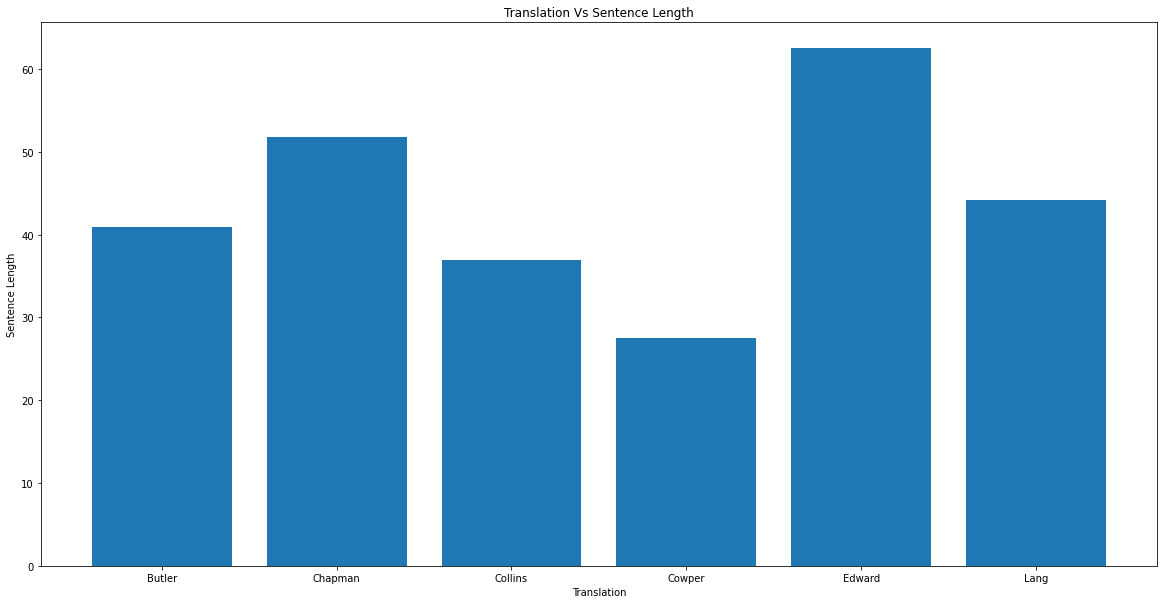

In [8]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.bar(Iliad_names, avgLength)
plt.title('Translation Vs Sentence Length')
plt.xlabel('Translation')
plt.ylabel('Sentence Length')
plt.show()

## Odyssey

In [9]:
avgLength = [] 
unigram_list = []
raregram_list = []
bigram_list = []
trigram_list = []

In [10]:
ngram(Odyssey)
counter = 0;
print('UNIGRAM FOR ODYSSEY (most common 10)\n')
for item in unigram_list:
    print(f'{Odyssey_names[counter]}: \n{item}')
    counter = counter+1

counter = 0;
print('\n\nRARE WORDS FOR ODYSSEY\n')
for item in raregram_list:
    print(f'{Odyssey_names[counter]}: \n{item}')
    counter = counter+1

counter = 0;
print('\n\nBIGRAMS FOR IILIAD (most common 5)\n')
for item in bigram_list:
    print(f'{Odyssey_names[counter]}: \n{item}')
    counter = counter+1
    
counter = 0;
print('\n\nTRIGRAMS FOR IILIAD (most common 5)\n')
for item in trigram_list:
    print(f'{Odyssey_names[counter]}: \n{item}')
    counter = counter+1

UNIGRAM FOR ODYSSEY (most common 10)

Butcher: 
[('thou', 930), ('spake', 657), ('odysseus', 651), ('thee', 640), ('thy', 619), ('even', 544), ('men', 520), ('come', 446), ('man', 438), ('one', 409)]
Butler: 
[('ulysses', 302), ('would', 146), ('telemachus', 137), ('suitors', 133), ('house', 129), ('one', 105), ('told', 105), ('men', 91), ('go', 89), ('went', 88)]
Collins: 
[('ulysses', 172), ('one', 74), ('father', 68), ('son', 63), ('telemachus', 63), ('even', 61), ('king', 61), ('upon', 58), ('old', 57), ('may', 56)]
Cowper: 
[('thou', 706), ('thy', 687), ('thus', 582), ('ulysses', 487), ('thee', 419), ('shall', 339), ('son', 310), ('yet', 271), ('gods', 235), ('jove', 222)]
POPE: 
[('thy', 802), ('thus', 409), ('ulysses', 332), ('er', 325), ('shall', 262), ('thou', 244), ('heaven', 205), ('man', 194), ('yet', 188), ('gods', 187)]


RARE WORDS FOR ODYSSEY

Butcher: 
[('glasses', 1), ('overthrown', 1), ('sky-nurtur', 1), ('eternally', 1), ('mystic', 1), ('enough—thy', 1), ('nilus', 1

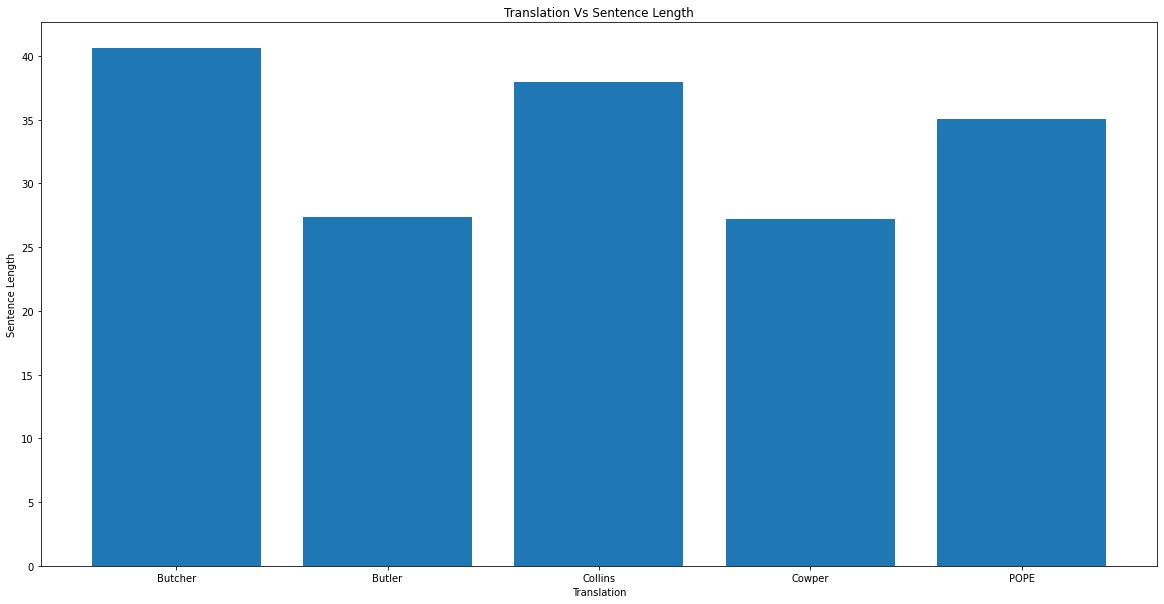

In [11]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.bar(Odyssey_names, avgLength)
plt.title('Translation Vs Sentence Length')
plt.xlabel('Translation')
plt.ylabel('Sentence Length')
plt.show()

## Some other NLTK Functions we explored

#### Here we are looking at for each of the versions, we are seeing how many percentages of texts are composed of stopwords
##### the result is pretty consistent -- all around 65%

In [12]:
# compute what fraction of words in a text are not in the stopwords list
def content_fraction(text):
    stopwords = nltk.corpus.stopwords.words('english')
    content = [w for w in text if w.lower() not in stopwords]
    print(len(content) / len(text))

In [13]:
for filename in Iliad:
    content_fraction(open(filename, 'r').read())

0.6687073122131397
0.6376652782013175
0.643119914556815
0.6443651906733016
0.6430617238730421
0.6308725508091063


In [14]:
for filename in Odyssey:
    content_fraction(open(filename, 'r').read())

0.636178465887905
0.6617972239250373
0.6439512099694931
0.6911094665569479
0.641520983655547


#### Here we are using a shorter corpus (TestCorpus) to test some other functionalities

In [15]:
# input a shorter corpus to test out other functions
myCorpus = open("./data/TestCorpus.txt", 'r').read()
myCorpus = preprocessing(myCorpus)

In [16]:
def extract_ngrams(data, num):
    n_grams = ngrams(nltk.word_tokenize(data), num)
    return [' '.join(grams) for grams in n_grams]

extract_ngrams(myCorpus, 5)[:5]

['The quarrel between Agamemnon and',
 'quarrel between Agamemnon and Achilles—Achilles',
 'between Agamemnon and Achilles—Achilles withdraws',
 'Agamemnon and Achilles—Achilles withdraws from',
 'and Achilles—Achilles withdraws from the']

In [17]:
def unusual_words(text):
    text_vocab = set(w.lower() for w in text if w.isalpha())
    english_vocab = set(w.lower() for w in nltk.corpus.words.words())
    unusual = text_vocab.difference(english_vocab)
    return sorted(unusual)
unusual_words(myCorpus)

['æ', 'œ']

##### The below graph shows what proportions of the text is taken up with such trigrams -- hence we are using cumulative frequency plot

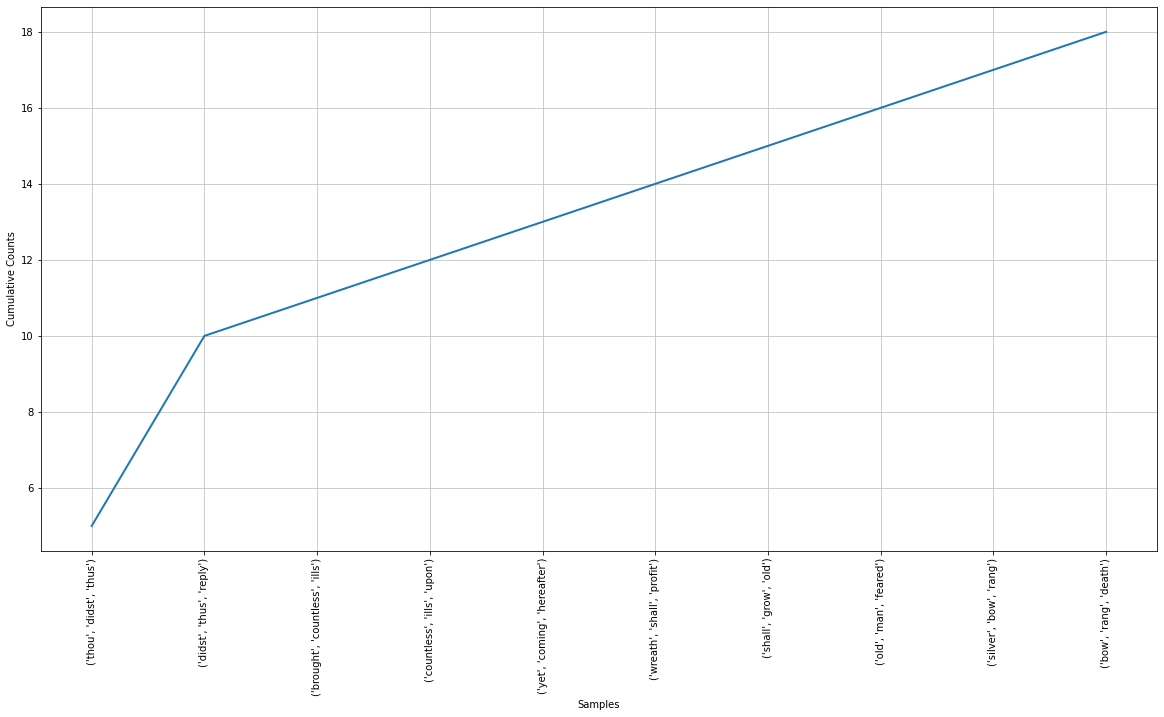

<AxesSubplot:xlabel='Samples', ylabel='Cumulative Counts'>

In [18]:
sentenceList = nltk.sent_tokenize(myCorpus)
sentence_tokenized = []

for sentence in sentenceList:
    sentence = list(nltk.word_tokenize(sentence))
    sentence_tokenized.append(sentence)

    stop_words = set(stopwords.words('english'))
    string.punctuation = string.punctuation +'"'+'"'+'-'+'''+'''+'—'+'”'+'“'+'_'+'’'
    removal_list = list(stop_words) + list(string.punctuation)+ list(string.digits) + ['said', '``','\'\'','\'d', '\'s','n','else.','r—a','_cyc._']

    trigram=[]
    tokenized_text=[]

    for sentence in sentence_tokenized:
        sentence = list(map(lambda x:x.lower(),sentence))
        for word in sentence:
            if word== '.':
                sentence.remove(word)
        trigram.extend(list(ngrams(sentence, 3, pad_left=False, pad_right=False)))

    trigram = remove_stopwords(trigram, removal_list)

trigram_freq = FreqDist(trigram)
trigram_freq.plot(10, cumulative=True)

 
 # Foreign Language Sentence Length Comparison
 
 
We decided to analyze the average length of sentences in 5 different languages (English, Spanish, French, Greek, Finnish) We wanted to see which languages were more "efficient" in conveying a story with less words per sentence. 

Our method first began with searching for non-english translations of either the Iliad or the Odyssey. This was the first difficulty that we came across. There were not many translations of either work in a foreign language. So our data is set is very small for each langauge. This emphasizes the probelm in NLP where less documented languages are diffucult to focus our projects on. We tried looking for Japanese or Chinese texts of the Iliad and Odyssey, but could not find one that was easily accessible, so the number of languages we could test was what was availible on project gutenburg. We couldn't find for example a Finnish copy of the Iliad to include. So we had to settle with the Odyssey copy to compare with. The fact that our usable data set is so small also means that our  computation of averages is not the most accurate result.    

Another difficulty of dealing with foreign languages is processing the files. On one hand the characters in other languages are not encoded in ASCII, so dealing with specfic special characters is not as easy as the english counterparts. Debugging is tricky because we are not fluent in greek, finnish, or french, so reading the output of our code is hard to tell if the sentences are being read correctly. 

Once we gathered our different texts we process out characters that we can distinguish as unneccsary in most of the languages. For example, in spanish we had to remove "--" because it was such a common occurance. We then use nltk.tokenize to tokenize our sentences. From there it is a simple loop to calculate the average. We also attempted to create n-gram models for the foriegn texts, however, we found that some characters were difficult to exclude as stopwords. This is potential for future work.  

The results show that English and Spanish are pretty similar in sentence length. This was to be exepcted as the two languages are not so different in terms of sentence structure. French and Greek were in fourth and third place respectively. The most interesting data point was Finnish sentence length on average being 15.35. This is because Finnish is an agglutinating language, where words are longer, but contain more complex meanings. Therefore, Finnish is able to get more meaning across using less words. 

 

In [19]:
# input the sentences

def foreign_avg(filePath,languageStop):
    myCorpus = open(filePath).read()
# preprocessing
    myCorpus = preprocessing(myCorpus)

    sentenceList = nltk.sent_tokenize(myCorpus)
    sentence_tokenized = [] 
    
    for sentence in sentenceList:
        sentence = list(nltk.word_tokenize(sentence))
        sentence_tokenized.append(sentence)
    
    numSentences = 0 
    sentencelengthTotal = 0 

    for sentence in sentence_tokenized:
        numSentences+= 1 
        sentencelengthTotal += len(sentence)
    
    avgSentenceLength =sentencelengthTotal/numSentences
    return(avgSentenceLength)

In [20]:
#Calculate avg sentence length of each languages given filepath and stopword dictionary 

avgSentenceLength_fin = foreign_avg("./data/finnish_test.txt",'finnish') 
avgSentenceLength_sp = foreign_avg("./data/spanish_test.txt",'spanish')
avgSentenceLength_gr = foreign_avg("./data/greek_test.txt",'greek')
avgSentenceLength_fr = foreign_avg("./data/french_test.txt",'french')
avgSentenceLength_en = foreign_avg("./data/english_test.txt",'english')

print(f'Average Finnish Sentence Length: {avgSentenceLength_fin}')

Average Finnish Sentence Length: 15.354954954954955


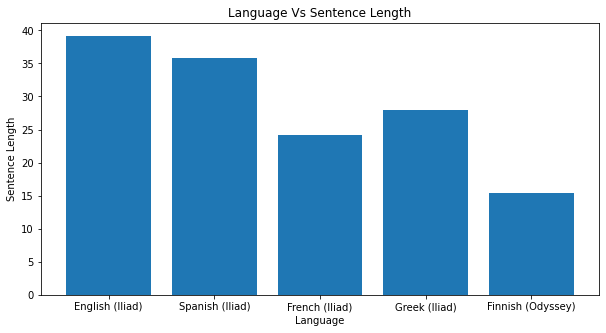

In [21]:
#Create bar graph for comparison using matplotlib 
Language = ['English (Iliad)','Spanish (Iliad)','French (Iliad)','Greek (Iliad)','Finnish (Odyssey)']
averageSentenceLengh_total = [avgSentenceLength_en,avgSentenceLength_sp,avgSentenceLength_fr,avgSentenceLength_gr,avgSentenceLength_fin]
plt.rcParams["figure.figsize"] = (10, 5)
plt.bar(Language, averageSentenceLengh_total)
plt.title('Language Vs Sentence Length')
plt.xlabel('Language')
plt.ylabel('Sentence Length')
plt.show()

## Acknowledgements  

 #### Collaborated with Dean 
 
 #### NLTK Documentation 
 
 https://www.nltk.org/book/ch02.html
 
 https://www.nltk.org/book/ch03.html
 
 https://www.nltk.org/book/ch06.html
 
 #### Text Referances
 
 Butcher & Lang
 
 https://www.gutenberg.org/files/1728/1728-0.txt
 
 George Chapman
 
 https://www.gutenberg.org/files/48895/48895-0.txt
 
 Butler
 
 https://www.gutenberg.org/cache/epub/1727/pg1727.txt
 https://www.gutenberg.org/cache/epub/2199/pg2199.txt
 
 Andrew Lang
 
 https://www.gutenberg.org/cache/epub/7972/pg7972.txt
 https://www.gutenberg.org/cache/epub/3059/pg3059.txt
 
 Iakovos Polylas
 
 https://www.gutenberg.org/cache/epub/55184/pg55184.txt
 
 Alexandros Pallis
 
 https://www.gutenberg.org/files/36248/36248-0.txt
 
 Jack London
 
 https://www.gutenberg.org/cache/epub/55184/pg55184.txt
 
 Alexander Pope
 
 https://www.gutenberg.org/files/3160/3160-0.txt
 https://www.gutenberg.org/cache/epub/6130/pg6130.txt
 
 William Cowper
 
 https://www.gutenberg.org/files/24269/24269-0.txt
 https://www.gutenberg.org/cache/epub/16452/pg16452.txt
 https://www.gutenberg.org/cache/epub/51355/pg51355.txt
 
 William Lucas Collins
 
 https://www.gutenberg.org/files/59306/59306-0.txt
 https://www.gutenberg.org/files/59306/59306-0.txt
 
 Leconte de Lisle 
 
 https://www.gutenberg.org/cache/epub/14285/pg14285.txt
 
 Edward, Earl of Derby
 
 https://www.gutenberg.org/files/6150/6150-0.txt
 
 Luis Segalá y Estalella
 
 https://www.gutenberg.org/files/57654/57654-0.txt
 
 #### How to useplot  
 
 https://datatofish.com/bar-chart-python-matplotlib/
 
 
 

